# ARIMA-Tools: Development and Testing

**Miguel A. Arranz**  
**Applied Time Series Econometrics (ATSE)**

---

This notebook is used for the development, testing, and validation of the
`ARIMA-Tools` Python library.

The library provides teaching-oriented tools for empirical ARIMA modelling,
complementing functionality available in `statsmodels` and `statsforecast`.

## Development objectives

The main areas of development are:

- AR and MA root diagnostics
- Causality and invertibility
- Common and near-common roots
- Residual diagnostics
- Recursive estimation and parameter stability
- Model selection
- Static and multi-step forecasting
- Reconstruction of forecasts on the original scale

Forecast evaluation and model comparison will be handled separately by
`Forecast-Tools`.

---

**Status:** Under development

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd

from statsmodels.tsa.arima.model import ARIMA

import arima_tools as at

/opt/homebrew/Caskroom/miniforge/base/envs/atse_arma_tools/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Simulated ARMA(1,1) Proecess

In [2]:
from statsmodels.tsa.arima_process import ArmaProcess

np.random.seed(12345)

# y_t = 0.7 y_{t-1} + eps_t + 0.4 eps_{t-1}
ar = np.array([1, -0.7])
ma = np.array([1, 0.4])

process = ArmaProcess(ar, ma)
y = process.generate_sample(nsample=1000)

result = ARIMA(y, order=(1, 0, 1), trend="n").fit()

print(result.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -1398.570
Date:                Mon, 05 Oct 2026   AIC                           2803.140
Time:                        16:12:00   BIC                           2817.863
Sample:                             0   HQIC                          2808.735
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6815      0.028     24.324      0.000       0.627       0.736
ma.L1          0.4130      0.035     11.948      0.000       0.345       0.481
sigma2         0.9588      0.042     22.892      0.0

In [3]:
print("AR parameters:", result.arparams)
print("MA parameters:", result.maparams)

print("AR roots:", result.arroots)
print("MA roots:", result.maroots)

AR parameters: [0.68146324]
MA parameters: [0.41301678]
AR roots: [1.46743059]
MA roots: [-2.42120913]


In [4]:
roots = at.root_diagnostics(result)
roots

,Type,Root,Value,Modulus,Inverse Root,Inverse Modulus
0,AR,1,1.467431,1.467431,0.681463,0.681463
1,MA,1,-2.421209,2.421209,-0.413017,0.413017


In [5]:
print("Causal:", at.is_causal(result))
print("Invertible:", at.is_invertible(result))

Causal: True
Invertible: True


In [6]:
at.common_roots(result)

,AR Root,MA Root,AR Inverse Root,MA Inverse Root,Distance,Classification


In [7]:
at.common_roots(result, tol=2.0)

,AR Root,MA Root,AR Inverse Root,MA Inverse Root,Distance,Classification
0,1,1,0.681463,-0.413017,1.09448,Near-common


In [8]:
at.root_summary(result)

Causal AR component        True
Invertible MA component    True
Common root pairs             0
Near-common root pairs        0
Minimum AR-MA distance      NaN
Name: Root diagnostics, dtype: object

In [9]:
at.coefficient_diagnostics(result)

,Coefficient,Estimate,Std. Error,z-statistic,P-value,95% CI Lower,95% CI Upper
0,ar.L1,0.681463,0.028016,24.323711,1.100401e-130,0.626552,0.736374
1,ma.L1,0.413017,0.034568,11.947951,6.654539e-33,0.345265,0.480769
2,sigma2,0.958818,0.041884,22.892302,5.543601e-116,0.876727,1.040909


In [10]:
at.parameter_correlation(result)

,ar.L1,ma.L1
ar.L1,1.000000,-0.507281
ma.L1,-0.507281,1.000000


In [11]:
at.parameter_correlation(result, include_variance=True)

,ar.L1,ma.L1,sigma2
ar.L1,1.000000,-0.507281,-0.021023
ma.L1,-0.507281,1.000000,-0.035651
sigma2,-0.021023,-0.035651,1.000000


In [12]:
at.ljung_box_test(result, lags=[5, 10, 20])

,Ljung-Box statistic,Degrees of freedom,P-value
Lag,,,
5,0.336264,3,0.953070
10,4.263639,8,0.832588
20,12.981030,18,0.792699


In [13]:
#at.ljung_box_test(result, lags=[1, 2, 5, 10])

In [14]:
at.residual_correlations(result, lags=20)

,Lag,ACF,PACF,Lower Bound,Upper Bound
0,1,0.004407,0.004407,-0.06198,0.06198
1,2,0.001682,0.001663,-0.06198,0.06198
2,3,-0.013058,-0.013073,-0.06198,0.06198
3,4,0.011889,0.012004,-0.06198,0.06198
4,5,0.000614,0.000551,-0.06198,0.06198
5,6,-0.000006,-0.000223,-0.06198,0.06198
6,7,0.037581,0.037906,-0.06198,0.06198
7,8,-0.033217,-0.033749,-0.06198,0.06198
8,9,-0.034616,-0.034512,-0.06198,0.06198
9,10,-0.013194,-0.011754,-0.06198,0.06198


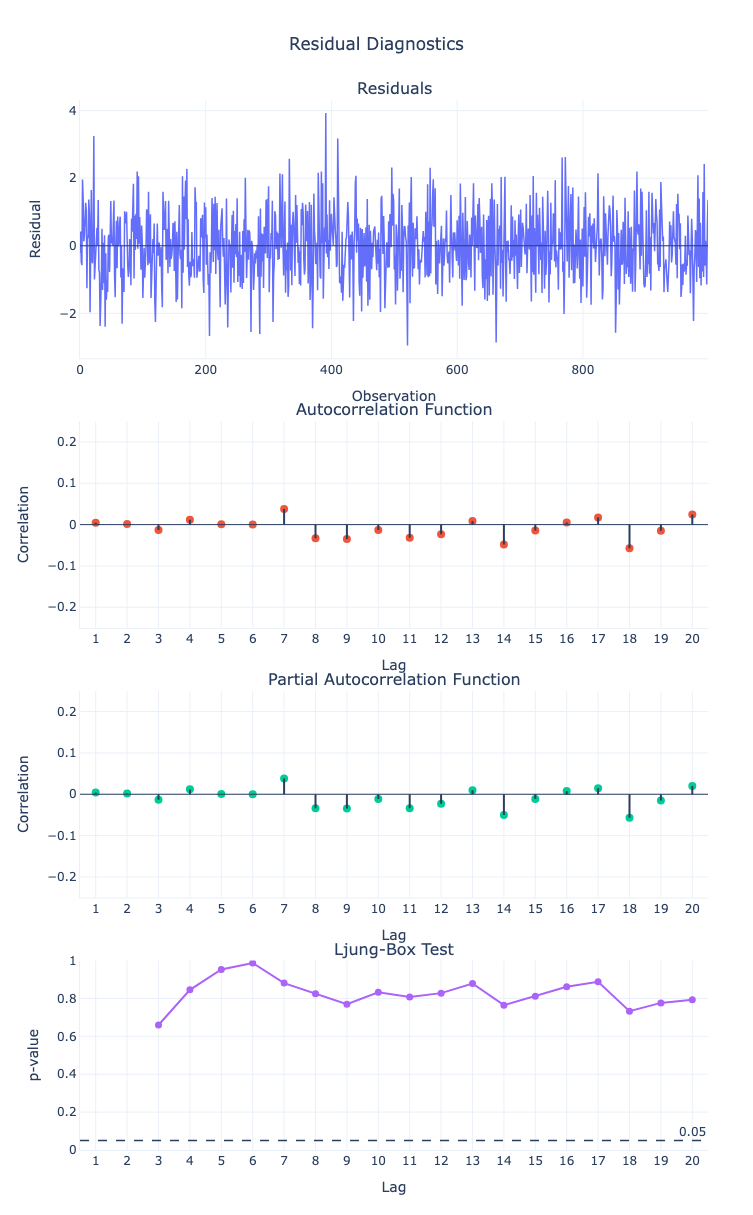

In [15]:
at.plot_residual_diagnostics(
    result,
    lags=20,
)

In [16]:
at.jarque_bera_test(result)

Jarque-Bera statistic    4.148883
Degrees of freedom       2.000000
P-value                  0.125627
Skewness                 0.149108
Kurtosis                 3.110988
Name: Jarque-Bera test, dtype: float64

In [17]:
at.dynamic_effects(result, horizon=20)

,Horizon,Dynamic Effect,Cumulative Effect
0,0,1.000000,1.000000
1,1,1.094480,2.094480
2,2,0.745848,2.840328
3,3,0.508268,3.348596
4,4,0.346366,3.694962
5,5,0.236036,3.930997
6,6,0.160850,4.091847
7,7,0.109613,4.201460
8,8,0.074697,4.276157
9,9,0.050903,4.327061


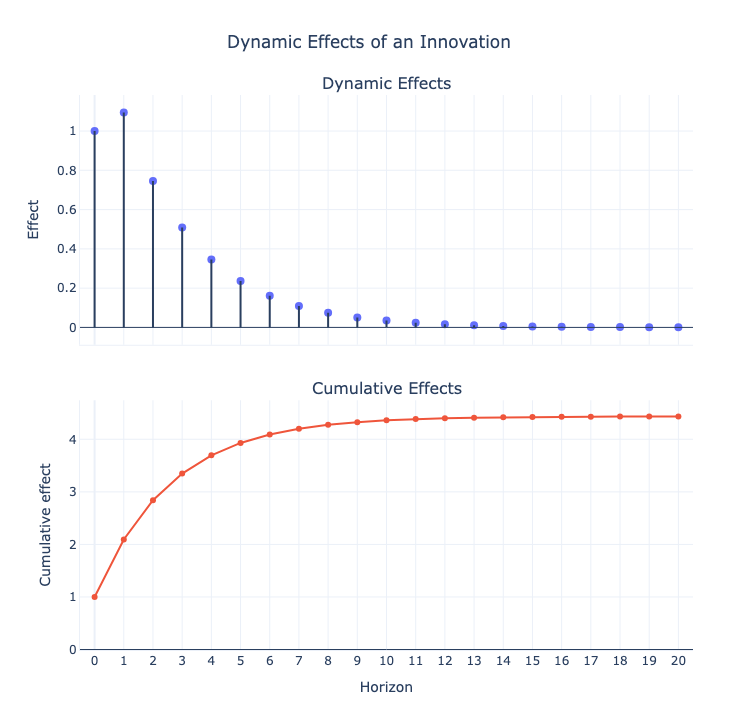

In [18]:
at.plot_dynamic_effects(
    result,
    horizon=20,
)

In [19]:
result_arma22 = ARIMA(
    y,
    order=(2, 0, 2),
    trend="n"
).fit()

result_arma22.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -1398.461
Date:                Mon, 05 Oct 2026   AIC                           2806.923
Time:                        16:12:02   BIC                           2831.461
Sample:                             0   HQIC                          2816.249
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3874      1.808      0.214      0.830      -3.156       3.931
ar.L2          0.1913      1.238      0.154      0.877      -2.236       2.619
ma.L1          0.7112      1.806      0.394      0.694      -2.828       4.250
ma.L2          0.1373      0.738      0.186      0.852      -1.309       1.583
sigma2         0.9586      0.042     22.785      0.000       0.876       1.041
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 4.18
Prob(Q):                              0.99   Prob(JB):                         0.12
Heteroskedasticity (H):               0.89   Skew:                             0.15
Prob(H) (two-sided):                  0.27   Kurtosis:                         3.10
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [20]:
at.joint_significance(
    result_arma22,
    ["ar.L2", "ma.L2"]
)

Wald statistic        0.249719
Degrees of freedom    2.000000
P-value               0.882621
Name: Joint significance test, dtype: float64

## Near-common roots

In [21]:
np.random.seed(2468)

# Near-cancelling ARMA(1,1):
# AR inverse root = 0.70
# MA inverse root = 0.68
ar_near = np.array([1, -0.70])
ma_near = np.array([1, -0.68])

process_near = ArmaProcess(ar_near, ma_near)
y_near = process_near.generate_sample(nsample=2000)

result_near = ARIMA(
    y_near,
    order=(1, 0, 1),
    trend="n"
).fit()

print("AR parameter:", result_near.arparams)
print("MA parameter:", result_near.maparams)

at.root_diagnostics(result_near)

AR parameter: [0.43039912]
MA parameter: [-0.40549696]


,Type,Root,Value,Modulus,Inverse Root,Inverse Modulus
0,AR,1,2.323425,2.323425,0.430399,0.430399
1,MA,1,2.466110,2.466110,0.405497,0.405497


In [22]:
at.common_roots(result_near, tol=0.05)

,AR Root,MA Root,AR Inverse Root,MA Inverse Root,Distance,Classification
0,1,1,0.430399,0.405497,0.024902,Near-common


In [23]:
at.root_summary(result_near)

Causal AR component            True
Invertible MA component        True
Common root pairs                 0
Near-common root pairs            1
Minimum AR-MA distance     0.024902
Name: Root diagnostics, dtype: object

In [24]:
at.parameter_correlation(result_near)

,ar.L1,ma.L1
ar.L1,1.000000,-0.999604
ma.L1,-0.999604,1.000000


In [25]:
at.ljung_box_test(result_near, lags=[5, 10, 20])

,Ljung-Box statistic,Degrees of freedom,P-value
Lag,,,
5,3.697160,3,0.296077
10,14.798773,8,0.063178
20,17.604941,18,0.481949


In [26]:
at.residual_correlations(result_near, lags=20)

,Lag,ACF,PACF,Lower Bound,Upper Bound
0,1,-0.001028,-0.001028,-0.043826,0.043826
1,2,-0.007978,-0.007979,-0.043826,0.043826
2,3,0.022316,0.022301,-0.043826,0.043826
3,4,-0.012212,-0.012241,-0.043826,0.043826
4,5,-0.033629,-0.033315,-0.043826,0.043826
5,6,0.007125,0.006391,-0.043826,0.043826
6,7,-0.030812,-0.030826,-0.043826,0.043826
7,8,0.043669,0.045187,-0.043826,0.043826
8,9,0.050257,0.048890,-0.043826,0.043826
9,10,-0.009450,-0.008352,-0.043826,0.043826


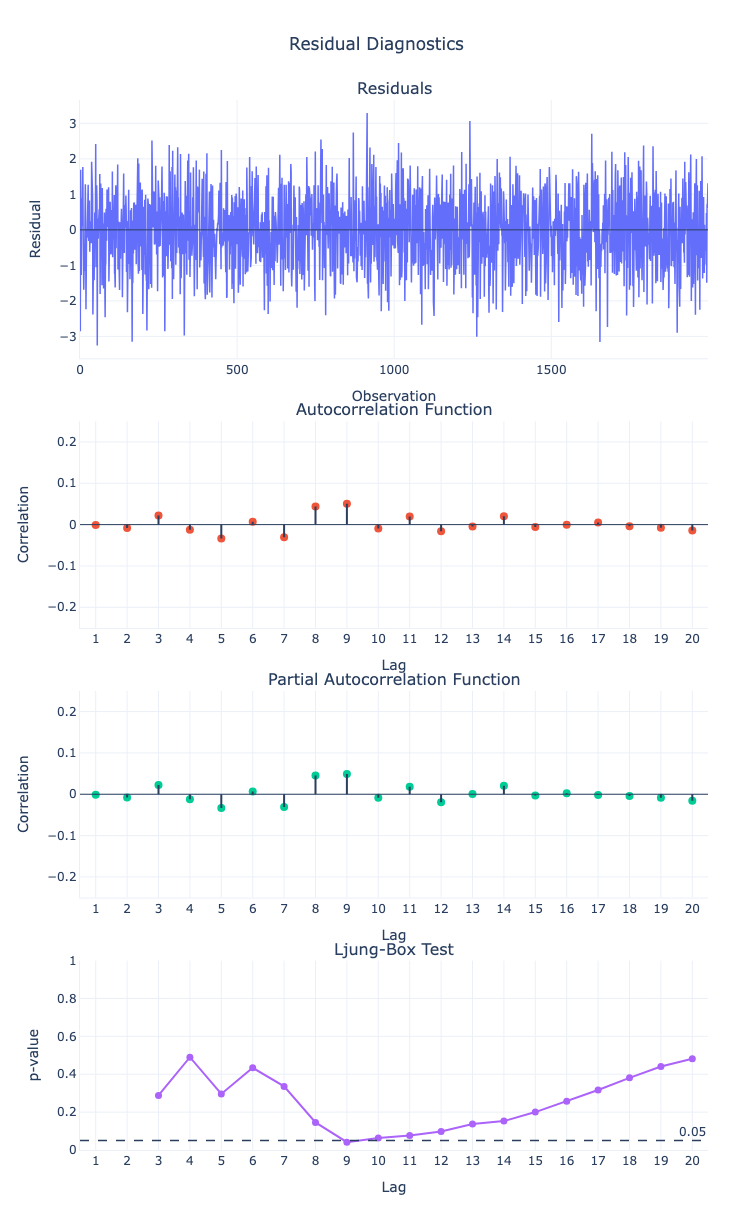

In [27]:
at.plot_residual_diagnostics(
    result_near,
    lags=20,
)

In [28]:
at.jarque_bera_test(result_near)

Jarque-Bera statistic    2.477895
Degrees of freedom       2.000000
P-value                  0.289689
Skewness                -0.068627
Kurtosis                 2.898225
Name: Jarque-Bera test, dtype: float64

In [29]:
at.dynamic_effects(result_near, horizon=20)

,Horizon,Dynamic Effect,Cumulative Effect
0,0,1.000000e+00,1.000000
1,1,2.490216e-02,1.024902
2,2,1.071787e-02,1.035620
3,3,4.612961e-03,1.040233
4,4,1.985415e-03,1.042218
5,5,8.545207e-04,1.043073
6,6,3.677849e-04,1.043441
7,7,1.582943e-04,1.043599
8,8,6.812974e-05,1.043667
9,9,2.932298e-05,1.043696


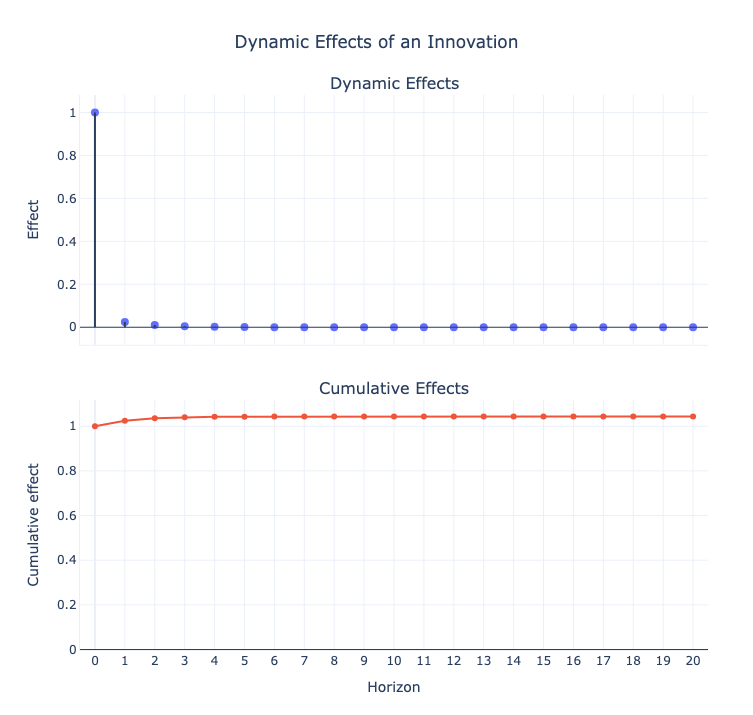

In [30]:
at.plot_dynamic_effects(
    result_near,
    horizon=20,
)

## AR(2) Complex Roots

In [31]:
np.random.seed(1357)

# AR(2) with complex-conjugate roots
# y_t = 1.2 y_{t-1} - 0.5 y_{t-2} + eps_t
ar_complex = np.array([1, -1.2, 0.5])
ma_complex = np.array([1])

process_complex = ArmaProcess(ar_complex, ma_complex)
y_complex = process_complex.generate_sample(nsample=2000)

result_complex = ARIMA(
    y_complex,
    order=(2, 0, 0),
    trend="n"
).fit()

print("AR parameters:", result_complex.arparams)

at.root_diagnostics(result_complex)

AR parameters: [ 1.21813126 -0.50164691]


,Type,Root,Value,Modulus,Inverse Root,Inverse Modulus
0,AR,1,1.214132-0.720637j,1.41189,0.609066+0.361505j,0.70827
1,AR,2,1.214132+0.720637j,1.41189,0.609066-0.361505j,0.70827


In [32]:
result_ar4 = ARIMA(
    y_complex,
    order=(4, 0, 0),
    trend="n"
).fit()

result_ar4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2000
Model:                 ARIMA(4, 0, 0)   Log Likelihood               -2816.054
Date:                Mon, 05 Oct 2026   AIC                           5642.107
Time:                        16:12:03   BIC                           5670.112
Sample:                             0   HQIC                          5652.390
                               - 2000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2217      0.022     56.290      0.000       1.179       1.264
ar.L2         -0.5048      0.035    -14.551      0.000      -0.573      -0.437
ar.L3         -0.0063      0.035     -0.181      0.856      -0.074       0.062
ar.L4          0.0111      0.022      0.494      0.621      -0.033       0.055
sigma2         0.9776      0.032     30.616      0.000       0.915       1.040
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 2.10
Prob(Q):                              0.98   Prob(JB):                         0.35
Heteroskedasticity (H):               0.87   Skew:                             0.05
Prob(H) (two-sided):                  0.07   Kurtosis:                         2.88
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [33]:
at.joint_significance(
    result_ar4,
    ["ar.L3", "ar.L4"]
)

Wald statistic        0.357838
Degrees of freedom    2.000000
P-value               0.836174
Name: Joint significance test, dtype: float64

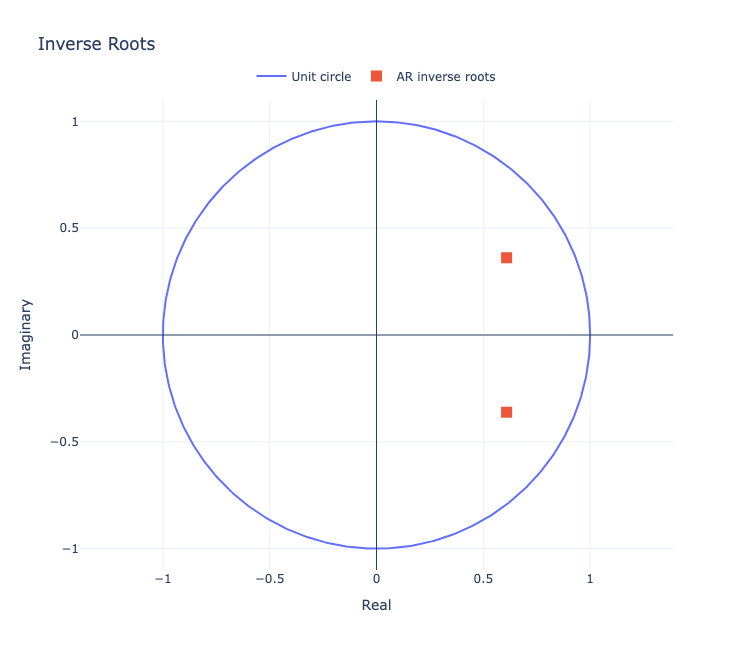

In [34]:
at.plot_inverse_roots(result_complex)

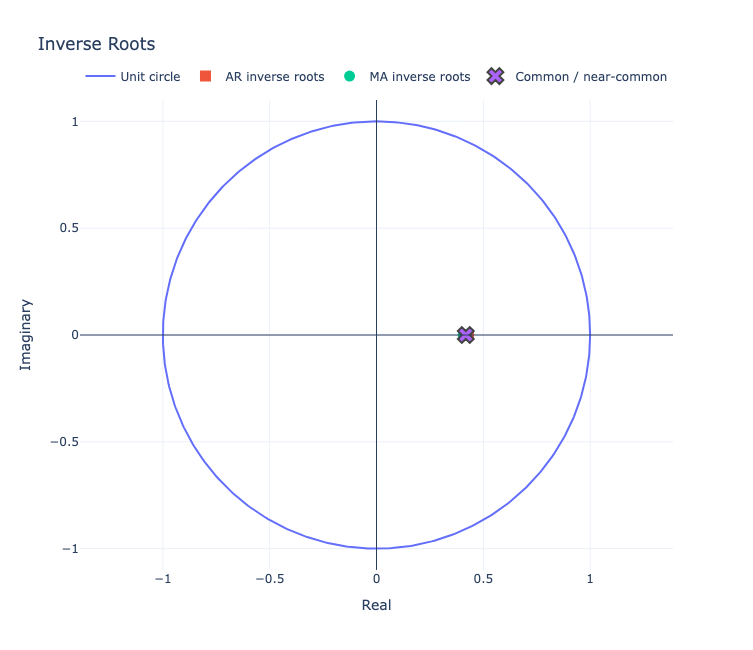

In [35]:
at.plot_inverse_roots(result_near)

In [36]:
at.root_summary(result_complex)

Causal AR component        True
Invertible MA component    True
Common root pairs             0
Near-common root pairs        0
Minimum AR-MA distance      NaN
Name: Root diagnostics, dtype: object

In [37]:
at.parameter_correlation(result_complex)

,ar.L1,ar.L2
ar.L1,1.000000,-0.812501
ar.L2,-0.812501,1.000000


In [38]:
at.joint_significance(
    result_complex,
    ["ar.L1", "ar.L2"]
)

Wald statistic        6186.003966
Degrees of freedom       2.000000
P-value                  0.000000
Name: Joint significance test, dtype: float64

In [39]:
at.ljung_box_test(result_complex, lags=[5, 10, 20])

,Ljung-Box statistic,Degrees of freedom,P-value
Lag,,,
5,1.785702,3,0.618051
10,4.954630,8,0.762414
20,11.922463,18,0.851215


In [40]:
at.residual_correlations(result_complex, lags=20)

,Lag,ACF,PACF,Lower Bound,Upper Bound
0,1,0.002885,0.002885,-0.043826,0.043826
1,2,0.000223,0.000215,-0.043826,0.043826
2,3,-0.017907,-0.017908,-0.043826,0.043826
3,4,-0.004654,-0.004552,-0.043826,0.043826
4,5,0.023225,0.023268,-0.043826,0.043826
5,6,-0.011008,-0.011470,-0.043826,0.043826
6,7,-0.011423,-0.011553,-0.043826,0.043826
7,8,-0.003803,-0.002909,-0.043826,0.043826
8,9,-0.032242,-0.032430,-0.043826,0.043826
9,10,-0.016441,-0.017343,-0.043826,0.043826


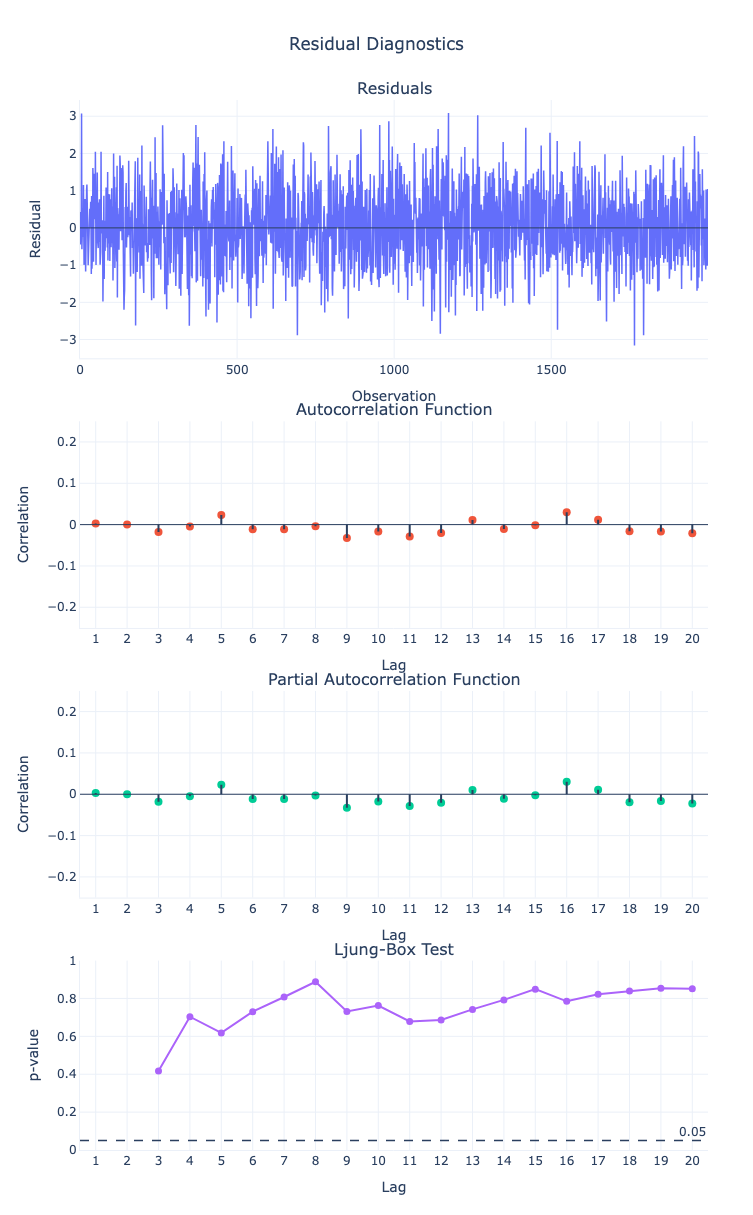

In [41]:
at.plot_residual_diagnostics(
    result_complex,
    lags=20,
)

In [42]:
at.jarque_bera_test(result_complex)

Jarque-Bera statistic    2.074076
Degrees of freedom       2.000000
P-value                  0.354503
Skewness                 0.051777
Kurtosis                 2.883622
Name: Jarque-Bera test, dtype: float64

In [43]:
at.dynamic_effects(result_complex, horizon=20)

,Horizon,Dynamic Effect,Cumulative Effect
0,0,1.000000,1.000000
1,1,1.218131,2.218131
2,2,0.982197,3.200328
3,3,0.585373,3.785701
4,4,0.220345,4.006046
5,5,-0.025241,3.980805
6,6,-0.141283,3.839522
7,7,-0.159439,3.680083
8,8,-0.123343,3.556740
9,9,-0.070266,3.486474


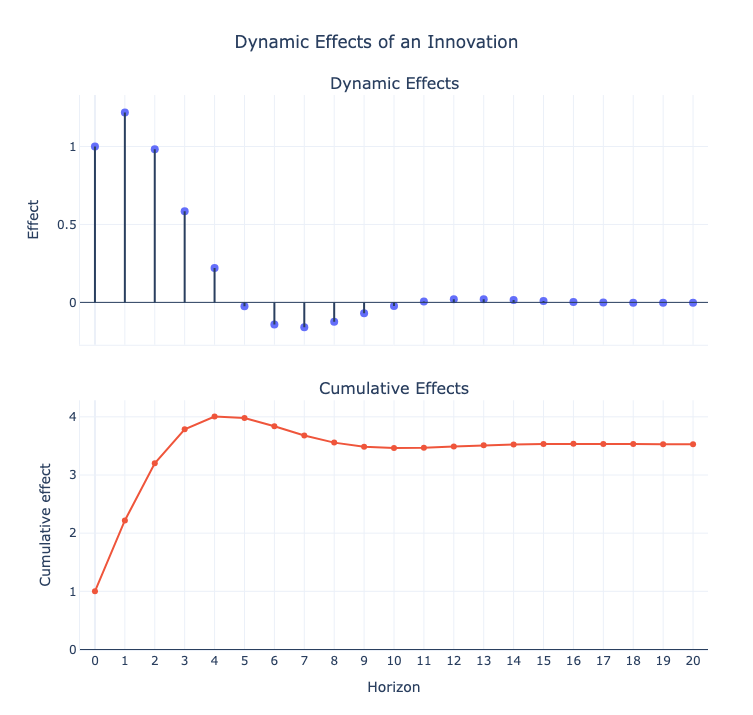

In [44]:
at.plot_dynamic_effects(
    result_complex,
    horizon=20,
)

In [45]:
at.compare_models(
    result,
    result_complex,
    names=["ARMA(1,1)", "AR(2)"],
)

,Order,N,Parameters,Log Likelihood,AIC,AICc,BIC,HQIC
Model,,,,,,,,
"ARMA(1,1)","(1, 0, 1)",1000,3,-1398.569800,2803.139600,2803.163696,2817.862866,2808.735468
AR(2),"(2, 0, 0)",2000,3,-2816.229994,5638.459988,5638.472012,5655.262696,5644.629590


In [46]:
search = at.order_search(
    y,
    p_max=3,
    q_max=3,
    criterion="BIC",
)

search

,Order,p,d,q,N,Parameters,Log Likelihood,AIC,AICc,BIC,HQIC,Converged,Status
0,"(1, 0, 1)",1,0,1,1000,4,-1398.565862,2805.131724,2805.171925,2824.762745,2812.592882,True,OK
1,"(1, 0, 2)",1,0,2,1000,5,-1398.485915,2806.971829,2807.032192,2831.510606,2816.298277,True,OK
2,"(2, 0, 1)",2,0,1,1000,5,-1398.492125,2806.984250,2807.044612,2831.523026,2816.310697,True,OK
3,"(3, 0, 0)",3,0,0,1000,5,-1399.326571,2808.653142,2808.713504,2833.191918,2817.979589,True,OK
4,"(1, 0, 3)",1,0,3,1000,6,-1398.423409,2808.846818,2808.931410,2838.293350,2820.038555,True,OK
5,"(3, 0, 1)",3,0,1,1000,6,-1398.423706,2808.847412,2808.932004,2838.293944,2820.039149,True,OK
6,"(2, 0, 2)",2,0,2,1000,6,-1398.457237,2808.914473,2808.999065,2838.361005,2820.106210,True,OK
7,"(2, 0, 0)",2,0,0,1000,4,-1406.969603,2821.939206,2821.979407,2841.570227,2829.400364,True,OK
8,"(3, 0, 2)",3,0,2,1000,7,-1398.414339,2810.828677,2810.941580,2845.182964,2823.885703,True,OK
9,"(2, 0, 3)",2,0,3,1000,7,-1398.423029,2810.846059,2810.958962,2845.200346,2823.903085,True,OK


In [47]:
print(search.loc[0, "Status"])

OK


In [48]:
at.select_model(search, criterion="BIC")

Order               (1, 0, 1)
p                           1
d                           0
q                           1
N                        1000
Parameters                  4
Log Likelihood   -1398.565862
AIC               2805.131724
AICc              2805.171925
BIC               2824.762745
HQIC              2812.592882
Converged                True
Status                     OK
Name: 0, dtype: object

In [49]:
search_i1 = at.order_search(
    y_complex,
    p_max=3,
    q_max=3,
    d_min=1,
    d_max=1,
    criterion="BIC",
)

search_i1

,Order,p,d,q,N,Parameters,Log Likelihood,AIC,AICc,BIC,HQIC,Converged,Status
0,"(2, 1, 1)",2,1,1,2000,4,-2816.627570,5641.255141,5641.275191,5663.656750,5649.480750,True,OK
1,"(3, 1, 1)",3,1,1,2000,5,-2816.582942,5643.165884,5643.195975,5671.167896,5653.447896,True,OK
2,"(2, 1, 2)",2,1,2,2000,5,-2816.584699,5643.169397,5643.199487,5671.171409,5653.451409,True,OK
3,"(3, 1, 2)",3,1,2,2000,6,-2815.683236,5643.366472,5643.408620,5676.968886,5655.704887,True,OK
4,"(2, 1, 3)",2,1,3,2000,6,-2816.429201,5644.858402,5644.900550,5678.460816,5657.196816,True,OK
5,"(1, 1, 3)",1,1,3,2000,5,-2838.435118,5686.870236,5686.900326,5714.872247,5697.152247,True,OK
6,"(1, 1, 2)",1,1,2,2000,4,-2886.379625,5780.759250,5780.779301,5803.160860,5788.984860,True,OK
7,"(3, 1, 0)",3,1,0,2000,4,-2975.718451,5959.436902,5959.456952,5981.838511,5967.662511,True,OK
8,"(2, 1, 0)",2,1,0,2000,3,-3011.733465,6029.466930,6029.478954,6046.268137,6035.636137,True,OK
9,"(0, 1, 3)",0,1,3,2000,4,-3010.449768,6028.899535,6028.919585,6051.301145,6037.125145,True,OK


In [50]:
search_all = at.order_search(
    y_complex,
    p_max=3,
    q_max=3,
    d_min=0,
    d_max=2,
    criterion="BIC",
)

search_all

,Order,p,d,q,N,Parameters,Log Likelihood,AIC,AICc,BIC,HQIC,Converged,Status
0,"(2, 0, 0)",2,0,0,2000,4,-2814.988647,5637.977293,5637.997343,5660.380903,5646.203429,True,OK
1,"(2, 1, 1)",2,1,1,2000,4,-2816.627570,5641.255141,5641.275191,5663.656750,5649.480750,True,OK
2,"(3, 0, 0)",3,0,0,2000,5,-2814.952510,5639.905019,5639.935110,5667.909532,5650.187689,True,OK
3,"(2, 0, 1)",2,0,1,2000,5,-2814.953913,5639.907827,5639.937917,5667.912339,5650.190497,True,OK
4,"(3, 1, 1)",3,1,1,2000,5,-2816.582942,5643.165884,5643.195975,5671.167896,5653.447896,True,OK
5,"(2, 1, 2)",2,1,2,2000,5,-2816.584699,5643.169397,5643.199487,5671.171409,5653.451409,True,OK
6,"(2, 0, 2)",2,0,2,2000,6,-2814.812376,5641.624753,5641.666900,5675.230167,5653.963956,True,OK
7,"(3, 0, 1)",3,0,1,2000,6,-2814.988601,5641.977202,5642.019349,5675.582616,5654.316405,True,OK
8,"(3, 1, 2)",3,1,2,2000,6,-2815.683236,5643.366472,5643.408620,5676.968886,5655.704887,True,OK
9,"(2, 1, 3)",2,1,3,2000,6,-2816.429201,5644.858402,5644.900550,5678.460816,5657.196816,True,OK


In [51]:
at.select_model(
    search_all,
    criterion="BIC",
)

Order               (2, 0, 0)
p                           2
d                           0
q                           0
N                        2000
Parameters                  4
Log Likelihood   -2814.988647
AIC               5637.977293
AICc              5637.997343
BIC               5660.380903
HQIC              5646.203429
Converged                True
Status                     OK
Name: 0, dtype: object

### Auto.Arima

In [52]:
auto = at.auto_arima(
    y_complex,
    criterion="BIC",
)

auto

AutoARIMA

In [53]:
hasattr(auto, "model_")

True

In [54]:
type(auto)

statsforecast.models.AutoARIMA

In [55]:
auto.__dict__.keys()

dict_keys(['d', 'D', 'max_p', 'max_q', 'max_P', 'max_Q', 'max_order', 'max_d', 'max_D', 'start_p', 'start_q', 'start_P', 'start_Q', 'stationary', 'seasonal', 'ic', 'stepwise', 'nmodels', 'trace', 'approximation', 'method', 'truncate', 'test', 'test_kwargs', 'seasonal_test', 'seasonal_test_kwargs', 'allowdrift', 'allowmean', 'blambda', 'biasadj', 'season_length', 'distribution', 'alias', 'prediction_intervals', 'model_'])

In [56]:
auto.model_.keys()

dict_keys(['coef', 'sigma2', 'var_coef', 'mask', 'loglik', 'aic', 'arma', 'residuals', 'code', 'n_cond', 'nobs', 'model', 'distribution', 'bic', 'aicc', 'ic', 'xreg', 'x', 'lambda'])

In [57]:
at.arima_string(auto.model_)

'ARIMA(2,0,0) with zero mean    '

In [58]:
for key in [
    "ic",
    "aic",
    "aicc",
    "bic",
    "loglik",
    "nobs",
    "sigma2",
]:
    print(key, ":", auto.model_.get(key))

ic : None
aic : 5638.459987990459
aicc : 5638.4720120385555
bic : 5655.262695369085
loglik : -2816.2299939952295
nobs : 2000
sigma2 : 0.9787559089854494


In [59]:
at.auto_arima_summary(auto)

Selected model                        ARIMA(2,0,0)
Deterministic component                       None
Interpretation             Zero unconditional mean
Selection criterion                            BIC
Criterion value                        5655.262695
AIC                                    5638.459988
AICc                                   5638.472012
BIC                                    5655.262695
Log Likelihood                        -2816.229994
Observations                                  2000
Innovation variance                       0.978756
Name: AutoARIMA Summary, dtype: object

### Recursive Estimation

In [60]:
recursive = at.recursive_estimation(
    y_complex,
    order=(2, 0, 0),
)

recursive.head(10)

,Endpoint,N,Parameter,Estimate,Std. Error,Lower CI,Upper CI,Converged
0,199,200,const,0.323671,0.216047,-0.099773,0.747116,True
1,199,200,ar.L1,1.258034,0.049107,1.161785,1.354282,True
2,199,200,ar.L2,-0.560557,0.057522,-0.673299,-0.447815,True
3,199,200,sigma2,0.838604,0.081266,0.679325,0.997883,True
4,200,201,const,0.308488,0.214294,-0.111521,0.728497,True
5,200,201,ar.L1,1.256361,0.049124,1.160080,1.352642,True
6,200,201,ar.L2,-0.561121,0.057531,-0.673881,-0.448362,True
7,200,201,sigma2,0.838697,0.081281,0.679389,0.998004,True
8,201,202,const,0.285568,0.213550,-0.132982,0.704117,True
9,201,202,ar.L1,1.262031,0.049435,1.165140,1.358921,True


In [61]:
recursive["N"].min()

np.int64(200)

In [62]:
recursive.groupby("N")["Converged"].first().value_counts()

Converged
True    1801
Name: count, dtype: int64

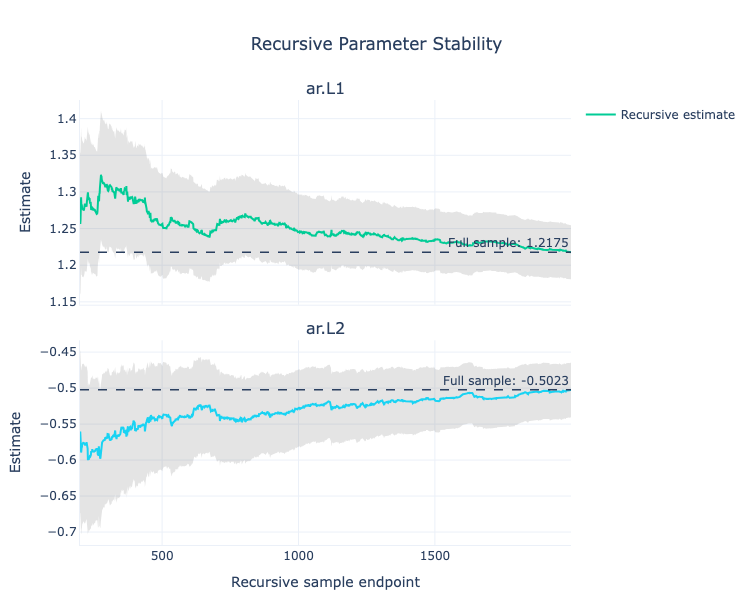

In [63]:
at.plot_parameter_stability(
    recursive,
    parameters=["ar.L1", "ar.L2"],
)

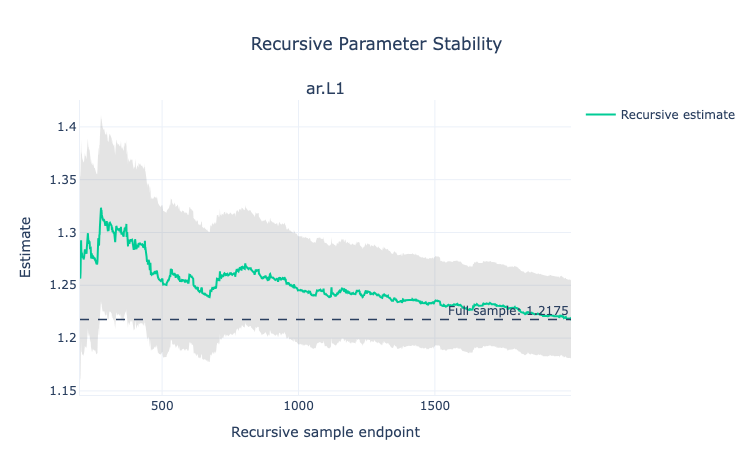

In [64]:
at.plot_parameter_stability(
    recursive,
    parameters="ar.L1",
)

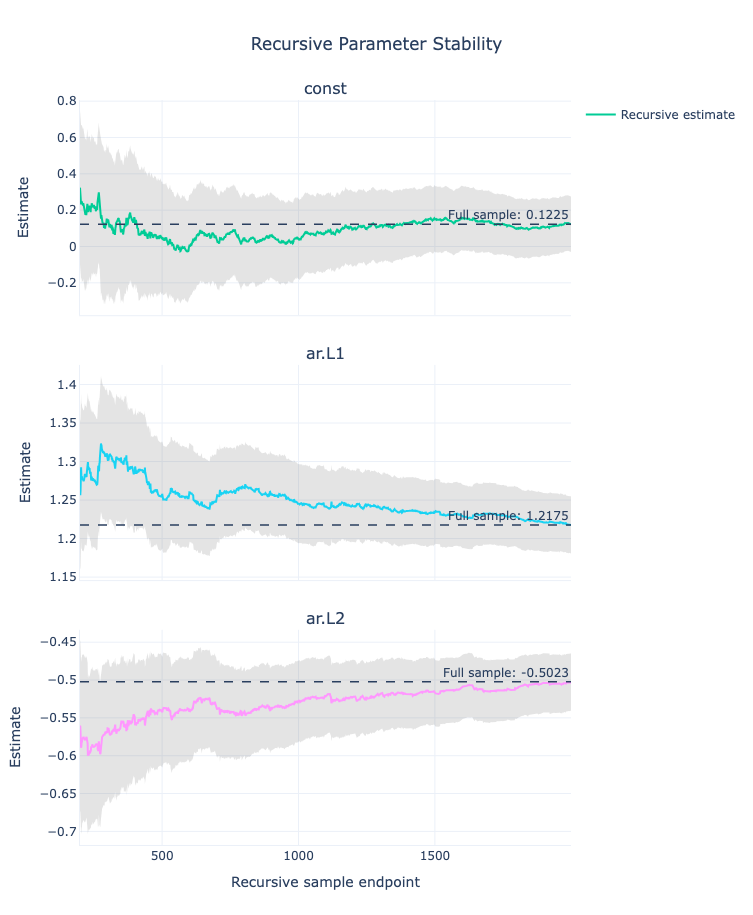

In [65]:
at.plot_parameter_stability(
    recursive,
)

## Simulated Structural Break

In [66]:
# ------------------------------------------------------------
# Structural-break test: AR(1)
# ------------------------------------------------------------

rng = np.random.default_rng(12345)

T = 500
break_point = 300

phi_1 = 0.40
phi_2 = 0.85

eps = rng.normal(size=T)
y_break = np.zeros(T)

for t in range(1, T):
    phi = phi_1 if t < break_point else phi_2
    y_break[t] = phi * y_break[t - 1] + eps[t]

y_break = pd.Series(
    y_break,
    index=pd.RangeIndex(start=1, stop=T + 1),
    name="y",
)

In [67]:
from statsmodels.tsa.arima.model import ARIMA

pre = ARIMA(
    y_break.iloc[:break_point],
    order=(1, 0, 0),
).fit()

post = ARIMA(
    y_break.iloc[break_point:],
    order=(1, 0, 0),
).fit()

print("Pre-break AR coefficient :", pre.arparams[0])
print("Post-break AR coefficient:", post.arparams[0])

Pre-break AR coefficient : 0.41917394731325136
Post-break AR coefficient: 0.8598655475742253


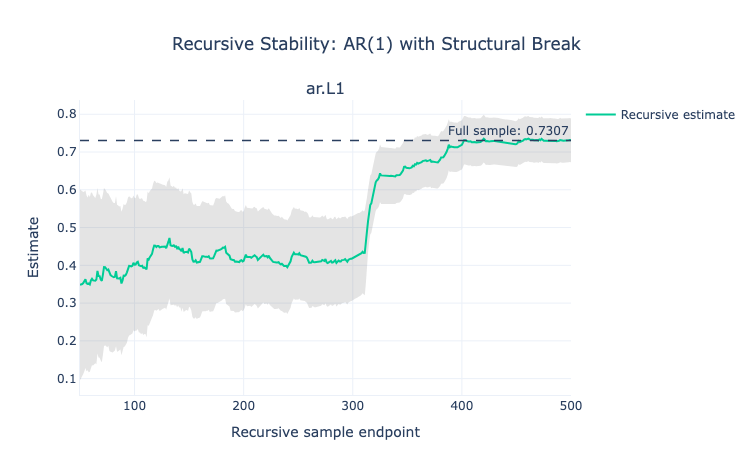

In [68]:
recursive_break = at.recursive_estimation(
    y_break,
    order=(1, 0, 0),
)

at.plot_parameter_stability(
    recursive_break,
    parameters="ar.L1",
    title="Recursive Stability: AR(1) with Structural Break",
)

In [69]:
recursive_break["N"].min()

np.int64(50)

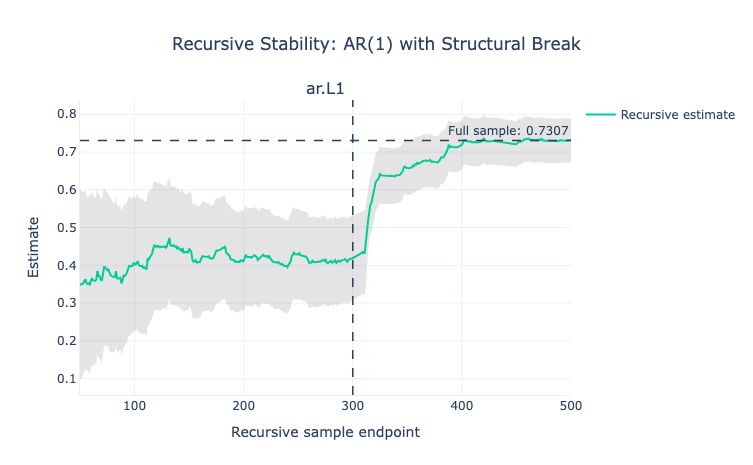

In [70]:
at.plot_parameter_stability(
    recursive_break,
    parameters="ar.L1",
    breakpoint=300,
    title="Recursive Stability: AR(1) with Structural Break",
)

## I(1) Process Auto.Arima

In [71]:
# ------------------------------------------------------------
# I(1) process with drift
# ------------------------------------------------------------

rng = np.random.default_rng(24680)

T = 500
drift = 0.20

eps = rng.normal(size=T)

y_drift = np.zeros(T)

for t in range(1, T):
    y_drift[t] = (
        y_drift[t - 1]
        + drift
        + eps[t]
    )

y_drift = pd.Series(
    y_drift,
    name="y_drift",
)

In [72]:
auto_drift = at.auto_arima(
    y_drift,
    criterion="BIC",
)

at.auto_arima_summary(auto_drift)

Selected model                                                  ARIMA(0,1,0)
Deterministic component                                                Drift
Interpretation             Constant in differenced model; linear drift in...
Selection criterion                                                      BIC
Criterion value                                                  1478.384383
AIC                                                              1469.959171
AICc                                                             1469.983364
BIC                                                              1478.384383
Log Likelihood                                                   -732.979585
Observations                                                             499
Innovation variance                                                   1.1094
Name: AutoARIMA Summary, dtype: object

In [73]:
print(at.auto_arima_summary(auto_drift)["Interpretation"])

Constant in differenced model; linear drift in level


# Forecasting

## AR(1)

In [74]:
import numpy as np
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima.model import ARIMA

rng = np.random.default_rng(12345)

ar = np.array([1, -0.8])
ma = np.array([1])

process = ArmaProcess(ar, ma)
y_forecast = process.generate_sample(
    nsample=250,
    distrvs=rng.standard_normal
)

result_ar1 = ARIMA(
    y_forecast,
    order=(1, 0, 0),
    trend="n"
).fit()

result_ar1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  250
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -346.961
Date:                Mon, 05 Oct 2026   AIC                            697.921
Time:                        16:13:37   BIC                            704.964
Sample:                             0   HQIC                           700.756
                                - 250                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8056      0.040     20.235      0.000       0.728       0.884
sigma2         0.9358      0.089     10.500      0.000       0.761       1.110
===================================================================================
Ljung-Box (L1) (Q):                   0.22   Jarque-Bera (JB):                 0.60
Prob(Q):                              0.64   Prob(JB):                         0.74
Heteroskedasticity (H):               1.02   Skew:                            -0.04
Prob(H) (two-sided):                  0.93   Kurtosis:                         2.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [75]:
h = 20

In [76]:
result_ar1.params

array([0.8055745 , 0.93577527])

In [77]:
phi_hat = result_ar1.params[0]
sigma2_hat = result_ar1.params[1]
h = 20

In [78]:
result_ar1.param_names

['ar.L1', 'sigma2']

In [79]:
result_ar1.param_names, result_ar1.params

(['ar.L1', 'sigma2'], array([0.8055745 , 0.93577527]))

In [80]:
params = dict(zip(result_ar1.param_names, result_ar1.params))

phi_hat = params["ar.L1"]
sigma2_hat = params["sigma2"]

h = 20
horizons = np.arange(1, h + 1)

In [81]:
fev_psi = np.array([
    sigma2_hat * np.sum(phi_hat ** (2 * np.arange(k)))
    for k in horizons
])

In [82]:
fev_closed = (
    sigma2_hat
    * (1 - phi_hat ** (2 * horizons))
    / (1 - phi_hat ** 2)
)

In [83]:
np.max(np.abs(fev_psi - fev_closed))

np.float64(8.881784197001252e-16)

In [84]:
unconditional_variance = sigma2_hat / (1 - phi_hat**2)

unconditional_variance

np.float64(2.665648744838547)

In [85]:
sm_forecast = result_ar1.get_forecast(steps=h)

In [86]:
sm_forecast.summary_frame()

y,mean,mean_se,mean_ci_lower,mean_ci_upper
0,1.494428,0.967355,-0.401553,3.390408
1,1.203873,1.242194,-1.230783,3.638529
2,0.969809,1.391810,-1.758089,3.697707
3,0.781254,1.480838,-2.121135,3.683642
4,0.629358,1.535853,-2.380859,3.639575
5,0.506995,1.570525,-2.571178,3.585167
6,0.408422,1.592621,-2.713058,3.529903
7,0.329014,1.606798,-2.820252,3.478281
8,0.265046,1.615932,-2.902122,3.432214
9,0.213514,1.621831,-2.965217,3.392245


In [87]:
sm_forecast = result_ar1.get_forecast(steps=h)

sm_forecast.summary_frame()

y,mean,mean_se,mean_ci_lower,mean_ci_upper
0,1.494428,0.967355,-0.401553,3.390408
1,1.203873,1.242194,-1.230783,3.638529
2,0.969809,1.391810,-1.758089,3.697707
3,0.781254,1.480838,-2.121135,3.683642
4,0.629358,1.535853,-2.380859,3.639575
5,0.506995,1.570525,-2.571178,3.585167
6,0.408422,1.592621,-2.713058,3.529903
7,0.329014,1.606798,-2.820252,3.478281
8,0.265046,1.615932,-2.902122,3.432214
9,0.213514,1.621831,-2.965217,3.392245


In [88]:
sm_forecast.var_pred_mean

array([0.93577527, 1.54304688, 1.93713596, 2.19288018, 2.35884545,
       2.46654867, 2.5364427 , 2.58180044, 2.61123537, 2.63033717,
       2.64273329, 2.65077775, 2.65599821, 2.65938603, 2.66158455,
       2.66301129, 2.66393717, 2.66453801, 2.66492794, 2.66518098])

In [89]:
fev_psi

array([0.93577527, 1.54304688, 1.93713596, 2.19288018, 2.35884545,
       2.46654867, 2.5364427 , 2.58180044, 2.61123537, 2.63033717,
       2.64273329, 2.65077775, 2.65599821, 2.65938603, 2.66158455,
       2.66301129, 2.66393717, 2.66453801, 2.66492794, 2.66518098])

In [90]:
sm_forecast = result_ar1.get_forecast(steps=h)

In [91]:
fev_sm = np.asarray(sm_forecast.var_pred_mean)

In [92]:
fev_sm

array([0.93577527, 1.54304688, 1.93713596, 2.19288018, 2.35884545,
       2.46654867, 2.5364427 , 2.58180044, 2.61123537, 2.63033717,
       2.64273329, 2.65077775, 2.65599821, 2.65938603, 2.66158455,
       2.66301129, 2.66393717, 2.66453801, 2.66492794, 2.66518098])

In [93]:
np.max(np.abs(fev_psi - fev_sm))

np.float64(4.440892098500626e-16)

In [94]:
comparison = pd.DataFrame({
    "Horizon": horizons,
    "Our FEV": fev_psi,
    "Statsmodels FEV": fev_sm,
    "Difference": fev_psi - fev_sm,
})

comparison

,Horizon,Our FEV,Statsmodels FEV,Difference
0,1,0.935775,0.935775,0.000000e+00
1,2,1.543047,1.543047,0.000000e+00
2,3,1.937136,1.937136,-2.220446e-16
3,4,2.192880,2.192880,0.000000e+00
4,5,2.358845,2.358845,0.000000e+00
5,6,2.466549,2.466549,0.000000e+00
6,7,2.536443,2.536443,0.000000e+00
7,8,2.581800,2.581800,4.440892e-16
8,9,2.611235,2.611235,4.440892e-16
9,10,2.630337,2.630337,4.440892e-16


In [95]:
at.forecast_error_variance(result_ar1, steps=20)

array([0.93577527, 1.54304688, 1.93713596, 2.19288018, 2.35884545,
       2.46654867, 2.5364427 , 2.58180044, 2.61123537, 2.63033717,
       2.64273329, 2.65077775, 2.65599821, 2.65938603, 2.66158455,
       2.66301129, 2.66393717, 2.66453801, 2.66492794, 2.66518098])

In [96]:
forecast_ar1 = at.dynamic_forecast(
    result_ar1,
    steps=20,
    level=0.95
)

forecast_ar1

,Forecast,FEV,SE,Lower,Upper
Horizon,,,,,
1,1.494428,0.935775,0.967355,-0.401553,3.390408
2,1.203873,1.543047,1.242194,-1.230783,3.638529
3,0.969809,1.937136,1.391810,-1.758089,3.697707
4,0.781254,2.192880,1.480838,-2.121135,3.683642
5,0.629358,2.358845,1.535853,-2.380859,3.639575
6,0.506995,2.466549,1.570525,-2.571178,3.585167
7,0.408422,2.536443,1.592621,-2.713058,3.529903
8,0.329014,2.581800,1.606798,-2.820252,3.478281
9,0.265046,2.611235,1.615932,-2.902122,3.432214


In [114]:
at.forecast_error_variance(result_ar1, steps=20)

array([0.93577527, 1.54304688, 1.93713596, 2.19288018, 2.35884545,
       2.46654867, 2.5364427 , 2.58180044, 2.61123537, 2.63033717,
       2.64273329, 2.65077775, 2.65599821, 2.65938603, 2.66158455,
       2.66301129, 2.66393717, 2.66453801, 2.66492794, 2.66518098])

In [115]:
forecast_ar1 = at.dynamic_forecast(
    result_ar1,
    steps=20,
    level=0.95
)

forecast_ar1

,Forecast,FEV,SE,Lower,Upper
Horizon,,,,,
1,1.494428,0.935775,0.967355,-0.401553,3.390408
2,1.203873,1.543047,1.242194,-1.230783,3.638529
3,0.969809,1.937136,1.391810,-1.758089,3.697707
4,0.781254,2.192880,1.480838,-2.121135,3.683642
5,0.629358,2.358845,1.535853,-2.380859,3.639575
6,0.506995,2.466549,1.570525,-2.571178,3.585167
7,0.408422,2.536443,1.592621,-2.713058,3.529903
8,0.329014,2.581800,1.606798,-2.820252,3.478281
9,0.265046,2.611235,1.615932,-2.902122,3.432214


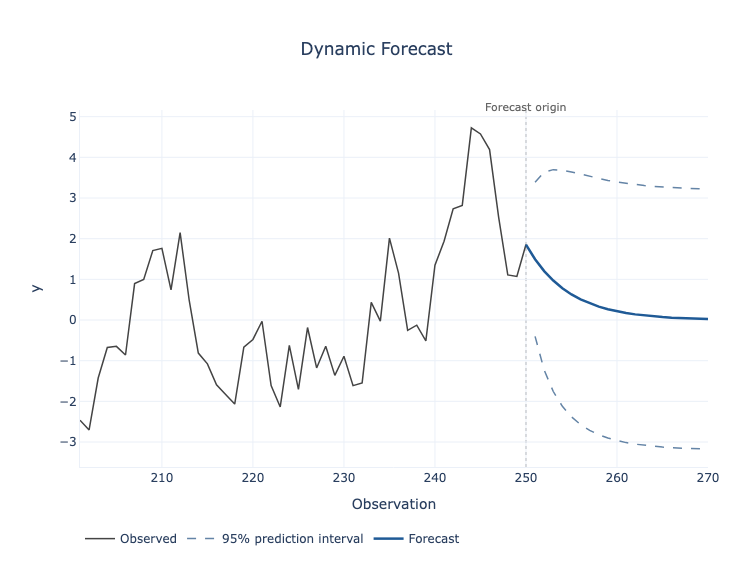

In [116]:
at.plot_forecast(
    result_ar1,
    steps=20,
    level=0.95,
    history=50
).show()

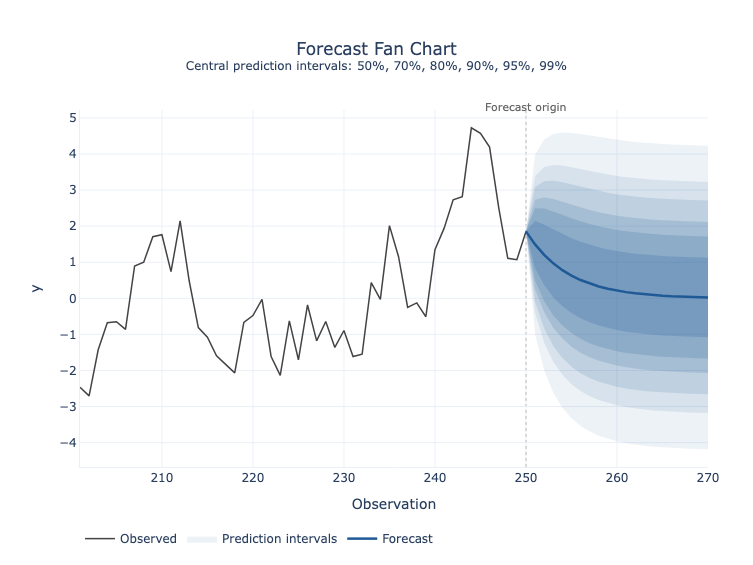

In [117]:
at.plot_fan_chart(
    result_ar1,
    steps=20,
    history=50
).show()

## ARMA(1,1)

In [97]:
rng = np.random.default_rng(54321)

ar = np.array([1, -0.7])
ma = np.array([1, 0.4])

process = ArmaProcess(ar, ma)

y_forecast_arma = process.generate_sample(
    nsample=250,
    distrvs=rng.standard_normal
)

result_arma11 = ARIMA(
    y_forecast_arma,
    order=(1, 0, 1),
    trend="n"
).fit()

result_arma11.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  250
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -340.414
Date:                Mon, 05 Oct 2026   AIC                            686.829
Time:                        16:13:37   BIC                            697.393
Sample:                             0   HQIC                           691.081
                                - 250                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8160      0.041     19.996      0.000       0.736       0.896
ma.L1          0.1798      0.070      2.586      0.010       0.044       0.316
sigma2         0.8868      0.075     11.755      0.000       0.739       1.035
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.75
Prob(Q):                              0.95   Prob(JB):                         0.69
Heteroskedasticity (H):               1.16   Skew:                            -0.06
Prob(H) (two-sided):                  0.50   Kurtosis:                         3.24
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [98]:
result_arma11.param_names, result_arma11.params

(['ar.L1', 'ma.L1', 'sigma2'], array([0.81601257, 0.17984857, 0.88675569]))

In [99]:
params = dict(zip(result_arma11.param_names, result_arma11.params))

phi_hat = params["ar.L1"]
theta_hat = params["ma.L1"]
sigma2_hat = params["sigma2"]

h = 20

psi = np.empty(h)
psi[0] = 1.0

for j in range(1, h):
    psi[j] = (phi_hat + theta_hat) * phi_hat**(j - 1)

psi

array([1.        , 0.99586114, 0.81263521, 0.66312054, 0.5411147 ,
       0.4415564 , 0.36031557, 0.29402203, 0.23992568, 0.19578237,
       0.15976087, 0.13036688, 0.10638101, 0.08680824, 0.07083662,
       0.05780357, 0.04716844, 0.03849004, 0.03140836, 0.02562961])

In [100]:
fev_psi_arma = np.array([
    sigma2_hat * np.sum(psi[:k]**2)
    for k in range(1, h + 1)
])

In [101]:
sm_forecast_arma = result_arma11.get_forecast(steps=h)
fev_sm_arma = np.asarray(sm_forecast_arma.var_pred_mean)

In [102]:
comparison_arma = pd.DataFrame({
    "Horizon": np.arange(1, h + 1),
    "Our FEV": fev_psi_arma,
    "Statsmodels FEV": fev_sm_arma,
    "Difference": fev_psi_arma - fev_sm_arma,
})

comparison_arma

,Horizon,Our FEV,Statsmodels FEV,Difference
0,1,0.886756,0.886756,-2.397038e-11
1,2,1.766186,1.766186,-1.596145e-11
2,3,2.351778,2.351778,-1.062883e-11
3,4,2.741710,2.741710,-7.077450e-12
4,5,3.001357,3.001357,-4.713119e-12
5,6,3.174250,3.174250,-3.138378e-12
6,7,3.289375,3.289375,-2.090328e-12
7,8,3.366034,3.366034,-1.391776e-12
8,9,3.417079,3.417079,-9.268142e-13
9,10,3.451069,3.451069,-6.172840e-13


In [103]:
np.max(np.abs(fev_psi_arma - fev_sm_arma))

np.float64(2.3970381235471905e-11)

In [104]:
fev_psi_arma[-1]

np.float64(3.517647369588333)

In [105]:
unconditional_variance_arma = sigma2_hat * (
    1
    + (phi_hat + theta_hat)**2 / (1 - phi_hat**2)
)

unconditional_variance_arma

np.float64(3.518808216124839)

## Random Walk

In [106]:
rng = np.random.default_rng(67890)

n = 250
eps = rng.standard_normal(n)

y_rw = np.cumsum(eps)

result_rw = ARIMA(
    y_rw,
    order=(0, 1, 0),
    trend="n"
).fit()

result_rw.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  250
Model:                 ARIMA(0, 1, 0)   Log Likelihood                -342.366
Date:                Mon, 05 Oct 2026   AIC                            686.733
Time:                        16:13:38   BIC                            690.250
Sample:                             0   HQIC                           688.149
                                - 250                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.9158      0.075     12.209      0.000       0.769       1.063
===================================================================================
Ljung-Box (L1) (Q):                   0.10   Jarque-Bera (JB):                 3.82
Prob(Q):                              0.76   Prob(JB):                         0.15
Heteroskedasticity (H):               0.67   Skew:                            -0.23
Prob(H) (two-sided):                  0.07   Kurtosis:                         3.39
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [107]:
result_rw.param_names, result_rw.params

(['sigma2'], array([0.91581115]))

In [108]:
params_rw = dict(zip(result_rw.param_names, result_rw.params))
sigma2_rw = params_rw["sigma2"]

h = 20
horizons = np.arange(1, h + 1)

In [109]:
fev_rw = horizons * sigma2_rw

In [110]:
sm_forecast_rw = result_rw.get_forecast(steps=h)
fev_sm_rw = np.asarray(sm_forecast_rw.var_pred_mean)

In [111]:
comparison_rw = pd.DataFrame({
    "Horizon": horizons,
    "Our FEV": fev_rw,
    "Statsmodels FEV": fev_sm_rw,
    "Difference": fev_rw - fev_sm_rw,
})

comparison_rw

,Horizon,Our FEV,Statsmodels FEV,Difference
0,1,0.915811,0.915811,4.254264e-12
1,2,1.831622,1.831622,4.254153e-12
2,3,2.747433,2.747433,4.253931e-12
3,4,3.663245,3.663245,4.253931e-12
4,5,4.579056,4.579056,4.253486e-12
5,6,5.494867,5.494867,4.253486e-12
6,7,6.410678,6.410678,4.253486e-12
7,8,7.326489,7.326489,4.253486e-12
8,9,8.242300,8.242300,4.254375e-12
9,10,9.158111,9.158111,4.254375e-12


In [112]:
np.max(np.abs(fev_rw - fev_sm_rw))

np.float64(4.259703700881801e-12)

In [113]:
at.dynamic_forecast(result_rw, steps=20, level=0.95)

,Forecast,FEV,SE,Lower,Upper
Horizon,,,,,
1,-0.72475,0.915811,0.956980,-2.600397,1.150897
2,-0.72475,1.831622,1.353374,-3.377315,1.927815
3,-0.72475,2.747433,1.657538,-3.973466,2.523965
4,-0.72475,3.663245,1.913960,-4.476044,3.026543
5,-0.72475,4.579056,2.139873,-4.918824,3.469324
6,-0.72475,5.494867,2.344113,-5.319128,3.869627
7,-0.72475,6.410678,2.531932,-5.687245,4.237745
8,-0.72475,7.326489,2.706749,-6.029880,4.580380
9,-0.72475,8.242300,2.870941,-6.351690,4.902190


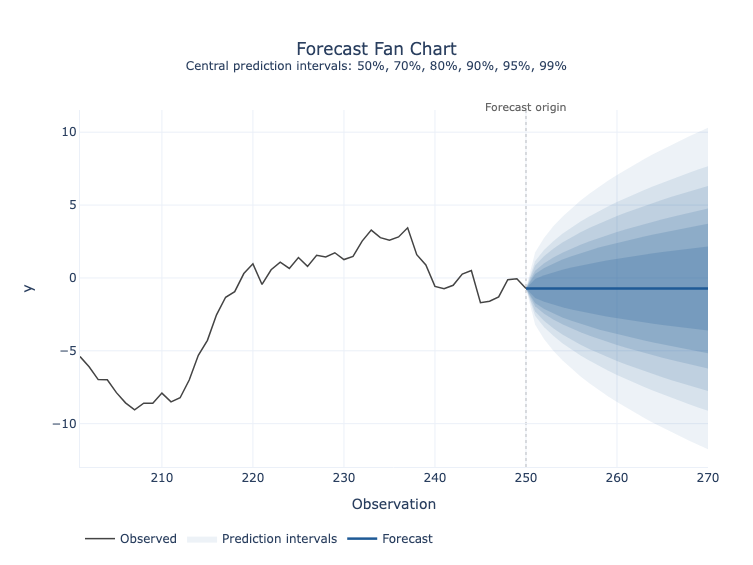

In [118]:
at.plot_fan_chart(
    result_rw,
    steps=20,
    history=50
).show()

In [119]:
fc_rw = at.dynamic_forecast(
    result_rw,
    steps=20,
    level=0.95
)

fc_rw.tail()

,Forecast,FEV,SE,Lower,Upper
Horizon,,,,,
16,-0.72475,14.652978,3.827921,-8.227337,6.777837
17,-0.72475,15.568790,3.945731,-8.458240,7.008740
18,-0.72475,16.484601,4.060123,-8.682445,7.232945
19,-0.72475,17.400412,4.171380,-8.900505,7.451005
20,-0.72475,18.316223,4.279746,-9.112898,7.663397


In [120]:
fc_rw.loc[20]

Forecast    -0.724750
FEV         18.316223
SE           4.279746
Lower       -9.112898
Upper        7.663397
Name: 20, dtype: float64

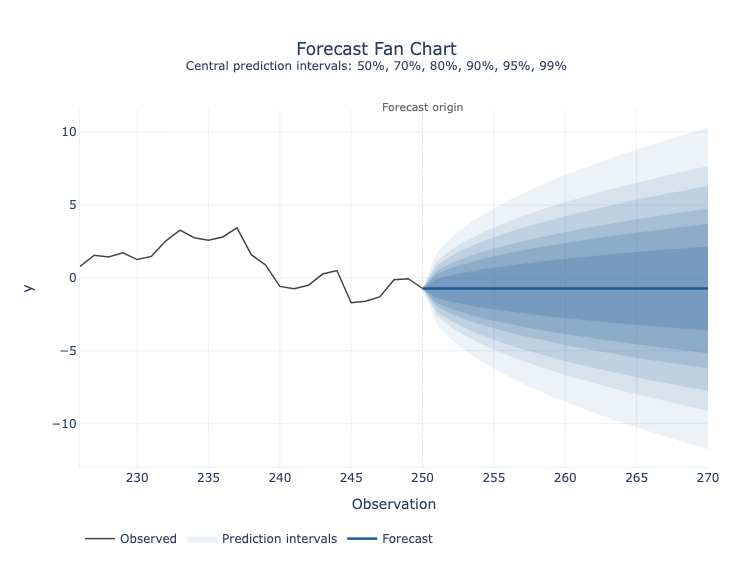

In [121]:
at.plot_fan_chart(
    result_rw,
    steps=20,
    history=25
).show()